In [1]:

#statistical summaries for the entire dataset first, followed by separate summaries for Vivinex and SA60AT
# correlation analysis with training-set-only
# training-set-only VIF analysis
# training-set-only RFE on the clinically prefiltered features
# comparison between 6-feature and 7-feature models Test set (held-out validation, not used for feature selection)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Upload the dataset
from google.colab import files
uploaded = files.upload()

Saving RelevantDataPONE-D-22-32900R1.xlsx to RelevantDataPONE-D-22-32900R1.xlsx


In [3]:
# Load the dataset
df = pd.read_excel('RelevantDataPONE-D-22-32900R1.xlsx')

In [4]:


print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Check unique IOL types
print(f"\nUnique IOL Types: {df['IOLtype'].unique()}")

# Define columns for statistical summary (exclude non-numeric or identifier columns)
numeric_cols = ['CCT', 'AQD', 'ACD', 'LT', 'AL', 'R1', 'R2', 'AXIS', 'K1', 'K2', 'WTW', 'IOL', 'SEQ']

# ============================================================================
# STATISTICAL SUMMARY FOR ENTIRE DATASET
# ============================================================================
print(f"\n{'='*80}")
print(f"STATISTICAL SUMMARY FOR ENTIRE DATASET (n={len(df)})")
print('='*80)

# Get statistical summary for all data
all_summary = df[numeric_cols].describe().loc[['count', 'mean', 'std', '25%', '50%', '75%']]
all_summary = all_summary.round(6)
print(all_summary.to_string())


# Check missing values in entire dataset
missing = df[numeric_cols].isnull().sum()
if missing.sum() > 0:
    print(f"\nMissing values in entire dataset:")
    print(missing[missing > 0])
else:
    print(f"\nNo missing values found in entire dataset")

# ============================================================================
#  SEPARATE DATA BY IOL TYPE
# ============================================================================
vivinex_df = df[df['IOLtype'] == 'Vivinex']
sa60at_df = df[df['IOLtype'] == 'SA60AT']

print(f"\nVivinex group size: {len(vivinex_df)}")
print(f"SA60AT group size: {len(sa60at_df)}")

# ============================================================================
#  STATISTICAL SUMMARY FOR VIVINEX GROUP
# ============================================================================
print(f"\n{'='*80}")
print(f"STATISTICAL SUMMARY FOR VIVINEX GROUP (n={len(vivinex_df)})")
print('='*80)

vivinex_summary = vivinex_df[numeric_cols].describe().loc[['count', 'mean', 'std', '25%', '50%', '75%']]
vivinex_summary = vivinex_summary.round(6)
print(vivinex_summary.to_string())


# Check missing values in Vivinex group
vivinex_missing = vivinex_df[numeric_cols].isnull().sum()
if vivinex_missing.sum() > 0:
    print(f"\nMissing values in Vivinex group:")
    print(vivinex_missing[vivinex_missing > 0])
else:
    print(f"\nNo missing values found in Vivinex group")

# ============================================================================
#  STATISTICAL SUMMARY FOR SA60AT GROUP
# ============================================================================
print(f"\n{'='*80}")
print(f"STATISTICAL SUMMARY FOR SA60AT GROUP (n={len(sa60at_df)})")
print('='*80)

sa60at_summary = sa60at_df[numeric_cols].describe().loc[['count', 'mean', 'std', '25%', '50%', '75%']]
sa60at_summary = sa60at_summary.round(6)
print(sa60at_summary.to_string())


# Check missing values in SA60AT group
sa60at_missing = sa60at_df[numeric_cols].isnull().sum()
if sa60at_missing.sum() > 0:
    print(f"\nMissing values in SA60AT group:")
    print(sa60at_missing[sa60at_missing > 0])
else:
    print(f"\nNo missing values found in SA60AT group")







Dataset Shape: (1710, 14)
Columns: ['IOLtype', 'CCT', 'AQD', 'ACD', 'LT', 'AL', 'R1', 'R2', 'AXIS', 'K1', 'K2', 'WTW', 'IOL', 'SEQ']

Unique IOL Types: ['Vivinex' 'SA60AT']

STATISTICAL SUMMARY FOR ENTIRE DATASET (n=1710)
               CCT          AQD          ACD           LT           AL           R1           R2        AXIS           K1           K2          WTW          IOL          SEQ
count  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  861.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000
mean    557.398244     2.561429     3.118827     4.617291    23.642370     7.821741     7.646411   91.379481    43.204344    44.196245     6.887930    21.635105    -0.522637
std      35.893513     0.413005     0.412429     0.446218     1.533590     0.280335     0.275612   61.678383     1.548774     1.609234     5.365830     4.300356     0.832744
25%     534.000000     2.286065     2.833250     4.330000    22.736983     7.63980

In [5]:
# ============================================================
# TRAIN/TEST SPLIT BEFORE ANY FEATURE ASSESSMENT
# ============================================================

from sklearn.model_selection import train_test_split

candidate_features = [
    "IOLtype",
    "CCT",
    "AQD",
    "ACD",
    "LT",
    "AL",
    "R1",
    "R2",
    "K1",
    "K2",
    "IOL"
]

target = "SEQ"

X_raw = df[candidate_features].copy()
y = df[target].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42

)

print("Training set:", X_train_raw.shape)
print("Test set:", X_test_raw.shape)
print("Training n:", len(X_train_raw))
print("Test n:", len(X_test_raw))

Training set: (1368, 11)
Test set: (342, 11)
Training n: 1368
Test n: 342


=== TRAINING-SET-ONLY CORRELATION ANALYSIS ===
Training dataset shape: (1368, 11)
Numeric columns: ['CCT', 'AQD', 'ACD', 'LT', 'AL', 'R1', 'R2', 'K1', 'K2', 'IOL', 'SEQ']

Correlation Matrix based only on training set:
       CCT    AQD    ACD     LT     AL     R1     R2     K1     K2    IOL  \
CCT  1.000 -0.068  0.019  0.005  0.038  0.197  0.202 -0.199 -0.203  0.086   
AQD -0.068  1.000  0.996 -0.636  0.561  0.046  0.052 -0.043 -0.050 -0.548   
ACD  0.019  0.996  1.000 -0.636  0.566  0.064  0.070 -0.060 -0.068 -0.542   
LT   0.005 -0.636 -0.636  1.000 -0.235 -0.008  0.017  0.002 -0.021  0.229   
AL   0.038  0.561  0.566 -0.235  1.000  0.345  0.330 -0.345 -0.328 -0.879   
R1   0.197  0.046  0.064 -0.008  0.345  1.000  0.882 -0.998 -0.877  0.055   
R2   0.202  0.052  0.070  0.017  0.330  0.882  1.000 -0.886 -0.999  0.059   
K1  -0.199 -0.043 -0.060  0.002 -0.345 -0.998 -0.886  1.000  0.883 -0.055   
K2  -0.203 -0.050 -0.068 -0.021 -0.328 -0.877 -0.999  0.883  1.000 -0.059   
IOL  0.086 

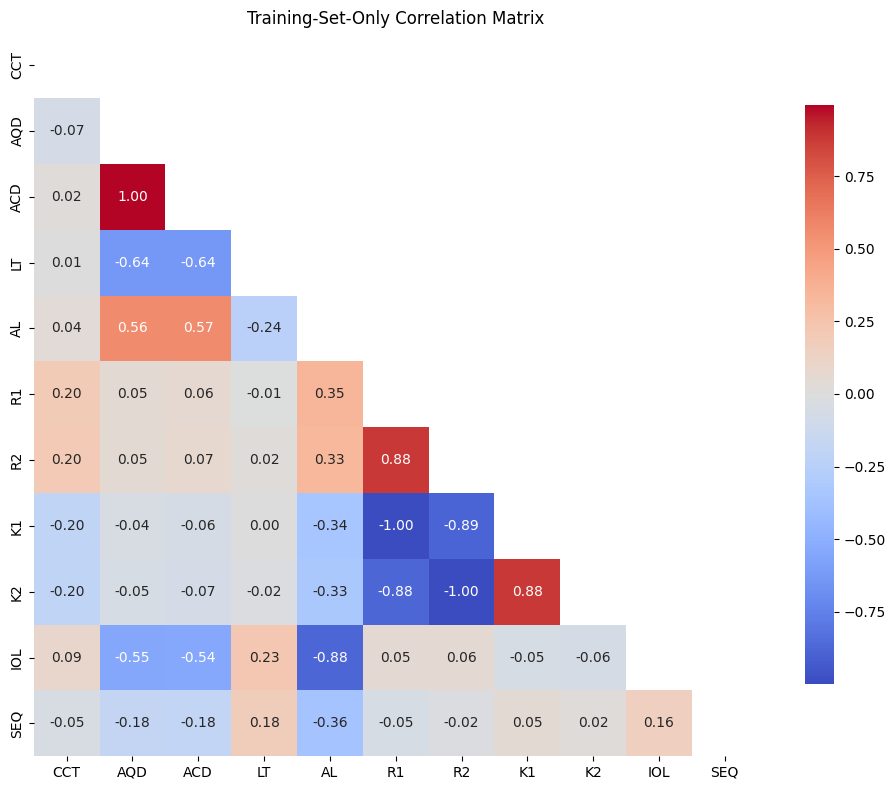


Strong correlations in training set only, |r| > 0.5:
AQD - ACD: 0.996
ACD - AQD: 0.996
K1 - K2: 0.883
K2 - K1: 0.883
R2 - R1: 0.882
R1 - R2: 0.882
ACD - AL: 0.566
AL - ACD: 0.566
AQD - AL: 0.561
AL - AQD: 0.561
ACD - IOL: -0.542
IOL - ACD: -0.542
AQD - IOL: -0.548
IOL - AQD: -0.548
LT - AQD: -0.636
AQD - LT: -0.636
LT - ACD: -0.636
ACD - LT: -0.636
R1 - K2: -0.877
K2 - R1: -0.877
AL - IOL: -0.879
IOL - AL: -0.879
K1 - R2: -0.886
R2 - K1: -0.886
R1 - K1: -0.998
K1 - R1: -0.998
R2 - K2: -0.999
K2 - R2: -0.999


In [6]:
# ============================================================
# Replace full-dataset correlation analysis with training-set-only correlation analysis
# TRAINING-SET-ONLY CORRELATION ANALYSIS
# ============================================================

train_corr_df = X_train_raw.copy()
train_corr_df[target] = y_train

numeric_train_df = train_corr_df.select_dtypes(include=[np.number])

print("=== TRAINING-SET-ONLY CORRELATION ANALYSIS ===")
print(f"Training dataset shape: {numeric_train_df.shape}")
print(f"Numeric columns: {list(numeric_train_df.columns)}")

corr_matrix_train = numeric_train_df.corr()

print("\nCorrelation Matrix based only on training set:")
print(corr_matrix_train.round(3))

print("\nCorrelation with SEQ based only on training set:")
print(
    corr_matrix_train[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .round(3)
)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix_train, dtype=bool))

sns.heatmap(
    corr_matrix_train,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8}
)

plt.title("Training-Set-Only Correlation Matrix")
plt.tight_layout()
plt.show()

threshold = 0.5

strong_correlations_train = corr_matrix_train[
    (corr_matrix_train.abs() > threshold) &
    (corr_matrix_train != 1.0)
]

strong_correlations_train = (
    strong_correlations_train
    .unstack()
    .dropna()
    .sort_values(ascending=False)
)

print(f"\nStrong correlations in training set only, |r| > {threshold}:")
if not strong_correlations_train.empty:
    for idx, value in strong_correlations_train.items():
        print(f"{idx[0]} - {idx[1]}: {value:.3f}")
else:
    print("No strong correlations found above the threshold.")

In [7]:
# ============================================================
# training-set-only VIF analysis
# TRAINING-SET-ONLY VIF ANALYSIS
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

numeric_candidate_features = [
    "CCT",
    "AQD",
    "ACD",
    "LT",
    "AL",
    "R1",
    "R2",
    "K1",
    "K2",
    "IOL"
]

X_train_vif = X_train_raw[numeric_candidate_features].copy()

vif_scaler = StandardScaler()
X_train_vif_scaled = pd.DataFrame(
    vif_scaler.fit_transform(X_train_vif),
    columns=numeric_candidate_features,
    index=X_train_vif.index
)

vif_table = pd.DataFrame({
    "Feature": X_train_vif_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_train_vif_scaled.values, i)
        for i in range(X_train_vif_scaled.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print("=== TRAINING-SET-ONLY VIF ANALYSIS ===")
display(vif_table)

=== TRAINING-SET-ONLY VIF ANALYSIS ===


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,CCT,inf
1,AQD,inf
2,ACD,inf
8,K2,772.357383
6,R2,770.117307
7,K1,650.308072
5,R1,642.328111
4,AL,16.290124
9,IOL,13.702695
3,LT,1.774407


In [8]:
# ============================================================
# CLINICALLY FEATURE PREFILTERING
# BASED ON TRAINING-SET-ONLY CORRELATION AND VIF ASSESSMENT
# ============================================================

# Excluded predictors:
# - AQD: highly redundant with ACD
# - R1 and R2: redundant with K1 and K2
# - CCT: weak association with SEQ and limited clinical relevance for IOL power prediction

clinically_prefiltered_features = [
    "IOLtype",
    "ACD",
    "LT",
    "AL",
    "K1",
    "K2",
    "IOL"
]

print("Clinically prefiltered features:")
print(clinically_prefiltered_features)

Clinically prefiltered features:
['IOLtype', 'ACD', 'LT', 'AL', 'K1', 'K2', 'IOL']


In [17]:
# ============================================================
# TRAINING-SET-ONLY RFE RANKING
# ============================================================

from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler

rfe_candidate_features = clinically_prefiltered_features.copy()

X_train_rfe = X_train_raw[rfe_candidate_features].copy()
X_test_rfe = X_test_raw[rfe_candidate_features].copy()

rfe_label_encoder = LabelEncoder()
X_train_rfe["IOLtype"] = rfe_label_encoder.fit_transform(X_train_rfe["IOLtype"])
X_test_rfe["IOLtype"] = rfe_label_encoder.transform(X_test_rfe["IOLtype"])

numeric_features_for_rfe = [
    col for col in rfe_candidate_features if col != "IOLtype"
]

rfe_scaler = StandardScaler()

X_train_rfe_scaled = X_train_rfe.copy()
X_test_rfe_scaled = X_test_rfe.copy()

X_train_rfe_scaled[numeric_features_for_rfe] = rfe_scaler.fit_transform(
    X_train_rfe[numeric_features_for_rfe]
)

X_test_rfe_scaled[numeric_features_for_rfe] = rfe_scaler.transform(
    X_test_rfe[numeric_features_for_rfe]
)

rfe_estimator = Ridge(alpha=1.0, random_state=42)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=6
)

rfe.fit(X_train_rfe_scaled, y_train)

rfe_results = pd.DataFrame({
    "Feature": X_train_rfe_scaled.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
}).sort_values(["Ranking", "Feature"])

print("=== TRAINING-SET-ONLY RFE RANKING RESULTS ===")
display(rfe_results)

rfe_selected_features = rfe_results.loc[
    rfe_results["Selected"],
    "Feature"
].tolist()

rfe_not_selected_features = rfe_results.loc[
    ~rfe_results["Selected"],
    "Feature"
].tolist()

print("\nRFE-selected features:")
print(rfe_selected_features)

print("\nFeatures not selected by RFE:")
print(rfe_not_selected_features)

=== TRAINING-SET-ONLY RFE RANKING RESULTS ===


,Feature,Selected,Ranking
1,ACD,True,1
3,AL,True,1
6,IOL,True,1
0,IOLtype,True,1
4,K1,True,1
5,K2,True,1
2,LT,False,2



RFE-selected features:
['ACD', 'AL', 'IOL', 'IOLtype', 'K1', 'K2']

Features not selected by RFE:
['LT']


In [9]:
# ============================================================
# comparison of RFE-SELECTED 6-feature model and 7-feature model with Test set
# ============================================================

feature_sets = {
    "RFE_6_features": [
        "IOLtype",
        "ACD",
        "AL",
        "K1",
        "K2",
        "IOL"
    ],

    "Clinical_7_features_with LT": [
        "IOLtype",
        "ACD",
        "LT",
        "AL",
        "K1",
        "K2",
        "IOL"
    ]

}


def prepare_train_test_data(X_train_raw, X_test_raw, feature_list):
    X_train = X_train_raw[feature_list].copy()
    X_test = X_test_raw[feature_list].copy()

    if "IOLtype" in feature_list:
        le = LabelEncoder()
        X_train["IOLtype"] = le.fit_transform(X_train["IOLtype"])
        X_test["IOLtype"] = le.transform(X_test["IOLtype"])

    cols_to_scale = [col for col in feature_list if col != "IOLtype"]

    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[cols_to_scale] = scaler.fit_transform(
        X_train[cols_to_scale]
    )

    X_test_scaled[cols_to_scale] = scaler.transform(
        X_test[cols_to_scale]
    )

    return X_train_scaled, X_test_scaled


def evaluate_stacking_model(X_train_scaled, X_test_scaled, y_train, y_test):

    base_learners = [
        ("mlp", MLPRegressor(
            random_state=42,
            max_iter=1000,
            activation="relu",
            alpha=0.1,
            hidden_layer_sizes=(200,),
            learning_rate_init=0.011724726450932652
        )),
        ("spline_linear", Pipeline([
            ("spline", SplineTransformer(degree=2, n_knots=6)),
            ("linear", LinearRegression())
        ])),
        ("svr", SVR(
            kernel="rbf",
            C=30,
            epsilon=0.1,
            gamma=0.03
        ))
    ]

    meta_learner = Ridge(random_state=42)

    stacking_reg = StackingRegressor(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5,
        passthrough=False,
        n_jobs=-1
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    cv_mae_scores = cross_val_score(
        stacking_reg,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error"
    )

    cv_rmse_scores = cross_val_score(
        stacking_reg,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )

    stacking_reg.fit(X_train_scaled, y_train)

    y_pred = stacking_reg.predict(X_test_scaled)

    abs_error = np.abs(y_test - y_pred)

    results = {
        "CV_MAE_mean": -np.mean(cv_mae_scores),
        "CV_MAE_sd": np.std(-cv_mae_scores),
        "CV_RMSE_mean": -np.mean(cv_rmse_scores),
        "CV_RMSE_sd": np.std(-cv_rmse_scores),
        "Test_MAE": mean_absolute_error(y_test, y_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "Test_R2": r2_score(y_test, y_pred),
        "Median_Absolute_Error": np.median(abs_error),
        "Within_0.25D": np.mean(abs_error <= 0.25) * 100,
        "Within_0.50D": np.mean(abs_error <= 0.50) * 100,
        "Within_0.75D": np.mean(abs_error <= 0.75) * 100,
        "Within_1.00D": np.mean(abs_error <= 1.00) * 100
    }

    return results, stacking_reg, y_pred


comparison_results = {}
trained_models = {}
predictions = {}

for model_name, feature_list in feature_sets.items():
    print(f"\n=== Evaluating {model_name} ===")
    print("Features:", feature_list)

    X_train_scaled_model, X_test_scaled_model = prepare_train_test_data(
        X_train_raw,
        X_test_raw,
        feature_list
    )

    results, model, y_pred_model = evaluate_stacking_model(
        X_train_scaled_model,
        X_test_scaled_model,
        y_train,
        y_test
    )

    comparison_results[model_name] = results
    trained_models[model_name] = model
    predictions[model_name] = y_pred_model

comparison_df = pd.DataFrame(comparison_results).T


print("\n=== MODEL COMPARISON: 6-FEATURE VS 7-FEATURE ===")
display(comparison_df.round(4))


=== Evaluating RFE_6_features ===
Features: ['IOLtype', 'ACD', 'AL', 'K1', 'K2', 'IOL']

=== Evaluating Clinical_7_features_with LT ===
Features: ['IOLtype', 'ACD', 'LT', 'AL', 'K1', 'K2', 'IOL']

=== MODEL COMPARISON: 6-FEATURE VS 7-FEATURE ===


,CV_MAE_mean,CV_MAE_sd,CV_RMSE_mean,CV_RMSE_sd,Test_MAE,Test_RMSE,Test_R2,Median_Absolute_Error,Within_0.25D,Within_0.50D,Within_0.75D,Within_1.00D
RFE_6_features,0.2964,0.0123,0.3858,0.0158,0.288,0.3744,0.7782,0.2363,51.7544,83.6257,95.3216,98.5380
Clinical_7_features_with LT,0.2896,0.0119,0.3731,0.0142,0.272,0.3476,0.8088,0.2255,53.2164,85.9649,95.9064,99.4152
